In [3]:
!pip install lightgbm
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 435.7 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/294.9 kB 558.5 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/294.9 kB 717.5 kB/s eta 0:00:01
   ------------------------------ --------- 225.3/294.9 kB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [106]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold, learning_curve, cross_validate
from lightgbm import LGBMRegressor
from sklearn.preprocessing import RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler, Nystroem
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error





In [2]:
df = pd.read_csv('rideshare_kaggle.csv')
df.head()

,id,timestamp,hour,day,month,datetime,timezone,source,destination,cab_type,...,precipIntensityMax,uvIndexTime,temperatureMin,temperatureMinTime,temperatureMax,temperatureMaxTime,apparentTemperatureMin,apparentTemperatureMinTime,apparentTemperatureMax,apparentTemperatureMaxTime
0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,1.544953e+09,9,16,12,2018-12-16 09:30:07,America/New_York,Haymarket Square,North Station,Lyft,...,0.1276,1544979600,39.89,1545012000,43.68,1544968800,33.73,1545012000,38.07,1544958000
1,4bd23055-6827-41c6-b23b-3c491f24e74d,1.543284e+09,2,27,11,2018-11-27 02:00:23,America/New_York,Haymarket Square,North Station,Lyft,...,0.1300,1543251600,40.49,1543233600,47.30,1543251600,36.20,1543291200,43.92,1543251600
2,981a3613-77af-4620-a42a-0c0866077d1e,1.543367e+09,1,28,11,2018-11-28 01:00:22,America/New_York,Haymarket Square,North Station,Lyft,...,0.1064,1543338000,35.36,1543377600,47.55,1543320000,31.04,1543377600,44.12,1543320000
3,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,1.543554e+09,4,30,11,2018-11-30 04:53:02,America/New_York,Haymarket Square,North Station,Lyft,...,0.0000,1543507200,34.67,1543550400,45.03,1543510800,30.30,1543550400,38.53,1543510800
4,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,1.543463e+09,3,29,11,2018-11-29 03:49:20,America/New_York,Haymarket Square,North Station,Lyft,...,0.0001,1543420800,33.10,1543402800,42.18,1543420800,29.11,1543392000,35.75,1543420800


In [3]:
df.columns

Index(['id', 'timestamp', 'hour', 'day', 'month', 'datetime', 'timezone',
       'source', 'destination', 'cab_type', 'product_id', 'name', 'price',
       'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature',
       'apparentTemperature', 'short_summary', 'long_summary',
       'precipIntensity', 'precipProbability', 'humidity', 'windSpeed',
       'windGust', 'windGustTime', 'visibility', 'temperatureHigh',
       'temperatureHighTime', 'temperatureLow', 'temperatureLowTime',
       'apparentTemperatureHigh', 'apparentTemperatureHighTime',
       'apparentTemperatureLow', 'apparentTemperatureLowTime', 'icon',
       'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex',
       'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase',
       'precipIntensityMax', 'uvIndexTime', 'temperatureMin',
       'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime',
       'apparentTemperatureMin', 'apparentTemperatureMinTime',
       'apparentTemperat

In [ ]:
def validate_ride_data(df):
    validation_report = {}

    validation_report['duplicate_ids'] = df['id'].duplicated().sum()
    validation_report['null_values'] = df.isnull().sum()[lambda x: x > 0].to_dict()

    validation_report['is_datetime_type'] = pd.api.types.is_datetime64_any_dtype(df['datetime'])
    temp_dt = pd.to_datetime(df['timestamp'], unit='s')
    
    expected_format = '%Y-%m-%d %H:%M:%S'
    formatted_dt = pd.to_datetime(df['datetime'], format=expected_format, errors='coerce')
    
    validation_report['invalid_datetime_format'] = formatted_dt.isna().sum()
    
    diff_seconds = (temp_dt - formatted_dt).dt.total_seconds().abs()

    validation_report['timestamp_datetime_mismatch'] = (diff_seconds > 3600).sum()

    validation_report['hour_mismatch'] = (temp_dt.dt.hour != df['hour']).sum()
    validation_report['month_mismatch'] = (temp_dt.dt.month != df['month']).sum()
    validation_report['day_mismatch'] = (temp_dt.dt.day != df['day']).sum()

    validation_report['invalid_days'] = ((df['day'] < 1) | (df['day'] > 31)).sum()
    validation_report['invalid_hours'] = ((df['hour'] < 0) | (df['hour'] > 23)).sum()
    validation_report['invalid_months'] = ((df['month'] < 1) | (df['month'] > 12)).sum()

    validation_report['invalid_price'] = (df['price'].dropna() <= 0).sum()
    validation_report['invalid_distance'] = (df['distance'] <= 0).sum()
    validation_report['invalid_surge'] = (df['surge_multiplier'] < 1.0).sum()
    
    validation_report['same_src_dest'] = (df['source'] == df['destination']).sum()

    validation_report['invalid_lat'] = ((df['latitude'] < -90) | (df['latitude'] > 90)).sum()
    validation_report['invalid_lon'] = ((df['longitude'] < -180) | (df['longitude'] > 180)).sum()

    prob_cols = ['precipProbability', 'humidity', 'cloudCover', 'moonPhase']
    for col in prob_cols:
        validation_report[f'out_of_bounds_{col}'] = ((df[col] < 0) | (df[col] > 1)).sum()

    validation_report['temp_range_error'] = (df['temperatureHigh'] < df['temperatureLow']).sum()
    
    validation_report['sunset_before_sunrise'] = (df['sunsetTime'] < df['sunriseTime']).sum()

    return validation_report

In [ ]:
report = pd.Series(validate_ride_data(df))
print(report)

duplicate_ids                                     0
null_values                        {'price': 55095}
is_datetime_type                              False
invalid_datetime_format                           0
timestamp_datetime_mismatch                       0
hour_mismatch                                     0
month_mismatch                                    0
day_mismatch                                      0
invalid_days                                      0
invalid_hours                                     0
invalid_months                                    0
invalid_price                                     0
invalid_distance                                  0
invalid_surge                                     0
same_src_dest                                     0
invalid_lat                                       0
invalid_lon                                       0
out_of_bounds_precipProbability                   0
out_of_bounds_humidity                            0
out_of_bound

In [6]:
df = df.dropna()
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
def plot_categorical(data, column, ax, title_prefix="Data"):
    unique_count = data[column].nunique()
    order = data[column].value_counts().index
    
    if unique_count > 15:
        sns.countplot(data=data, y=column, order=order[:15], ax=ax, palette='viridis')
        ax.set_title(f"{title_prefix}: {column} (Top 15 of {unique_count})")
    else:
        sns.countplot(data=data, x=column, order=order, ax=ax, palette='Set2')
        ax.set_title(f"{title_prefix}: {column} ({unique_count} unique)")
        ax.tick_params(axis='x', rotation=45)

def plot_numerical(data, column, ax, title_prefix="Data"):
    sns.histplot(data[column], bins=30, ax=ax, color='teal')
    ax.set_title(f"{title_prefix}: {column} Range")
    ax.tick_params(axis='x', rotation=45)

def plot_dataset(data, columns, title_prefix="Data"):
    n_cols = len(columns)
    nrows = (n_cols + 1) // 2
    
    fig, axes = plt.subplots(nrows, 2, figsize=(18, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for i, col in enumerate(columns):
        if pd.api.types.is_datetime64_any_dtype(data[col]) or pd.api.types.is_numeric_dtype(data[col]):
            plot_numerical(data, col, axes_flat[i], title_prefix)        
        else:
            plot_categorical(data, col, axes_flat[i], title_prefix)
            
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
        
    plt.tight_layout()
    plt.show()

In [8]:
cat_cols = df.select_dtypes(exclude=['number', 'datetime']).columns.tolist()
num_cols = df.select_dtypes(include=['number', 'datetime']).columns.tolist()
cat_cols.pop(0)

print(cat_cols)
print(num_cols)
assert len(cat_cols) + len(num_cols) == len(df.columns) - 1

['timezone', 'source', 'destination', 'cab_type', 'product_id', 'name', 'short_summary', 'long_summary', 'icon']
['timestamp', 'hour', 'day', 'month', 'datetime', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'windGustTime', 'visibility', 'temperatureHigh', 'temperatureHighTime', 'temperatureLow', 'temperatureLowTime', 'apparentTemperatureHigh', 'apparentTemperatureHighTime', 'apparentTemperatureLow', 'apparentTemperatureLowTime', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'visibility.1', 'ozone', 'sunriseTime', 'sunsetTime', 'moonPhase', 'precipIntensityMax', 'uvIndexTime', 'temperatureMin', 'temperatureMinTime', 'temperatureMax', 'temperatureMaxTime', 'apparentTemperatureMin', 'apparentTemperatureMinTime', 'apparentTemperatureMax', 'apparentTemperatureMaxTime']


C:\Users\pc\AppData\Local\Temp\ipykernel_25184\1384934160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=column, order=order, ax=ax, palette='Set2')
C:\Users\pc\AppData\Local\Temp\ipykernel_25184\1384934160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=column, order=order, ax=ax, palette='Set2')
C:\Users\pc\AppData\Local\Temp\ipykernel_25184\1384934160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=column, order=order, ax=ax, palette='Set2')
C:\Users\pc\AppData\Local\Temp\ipyker

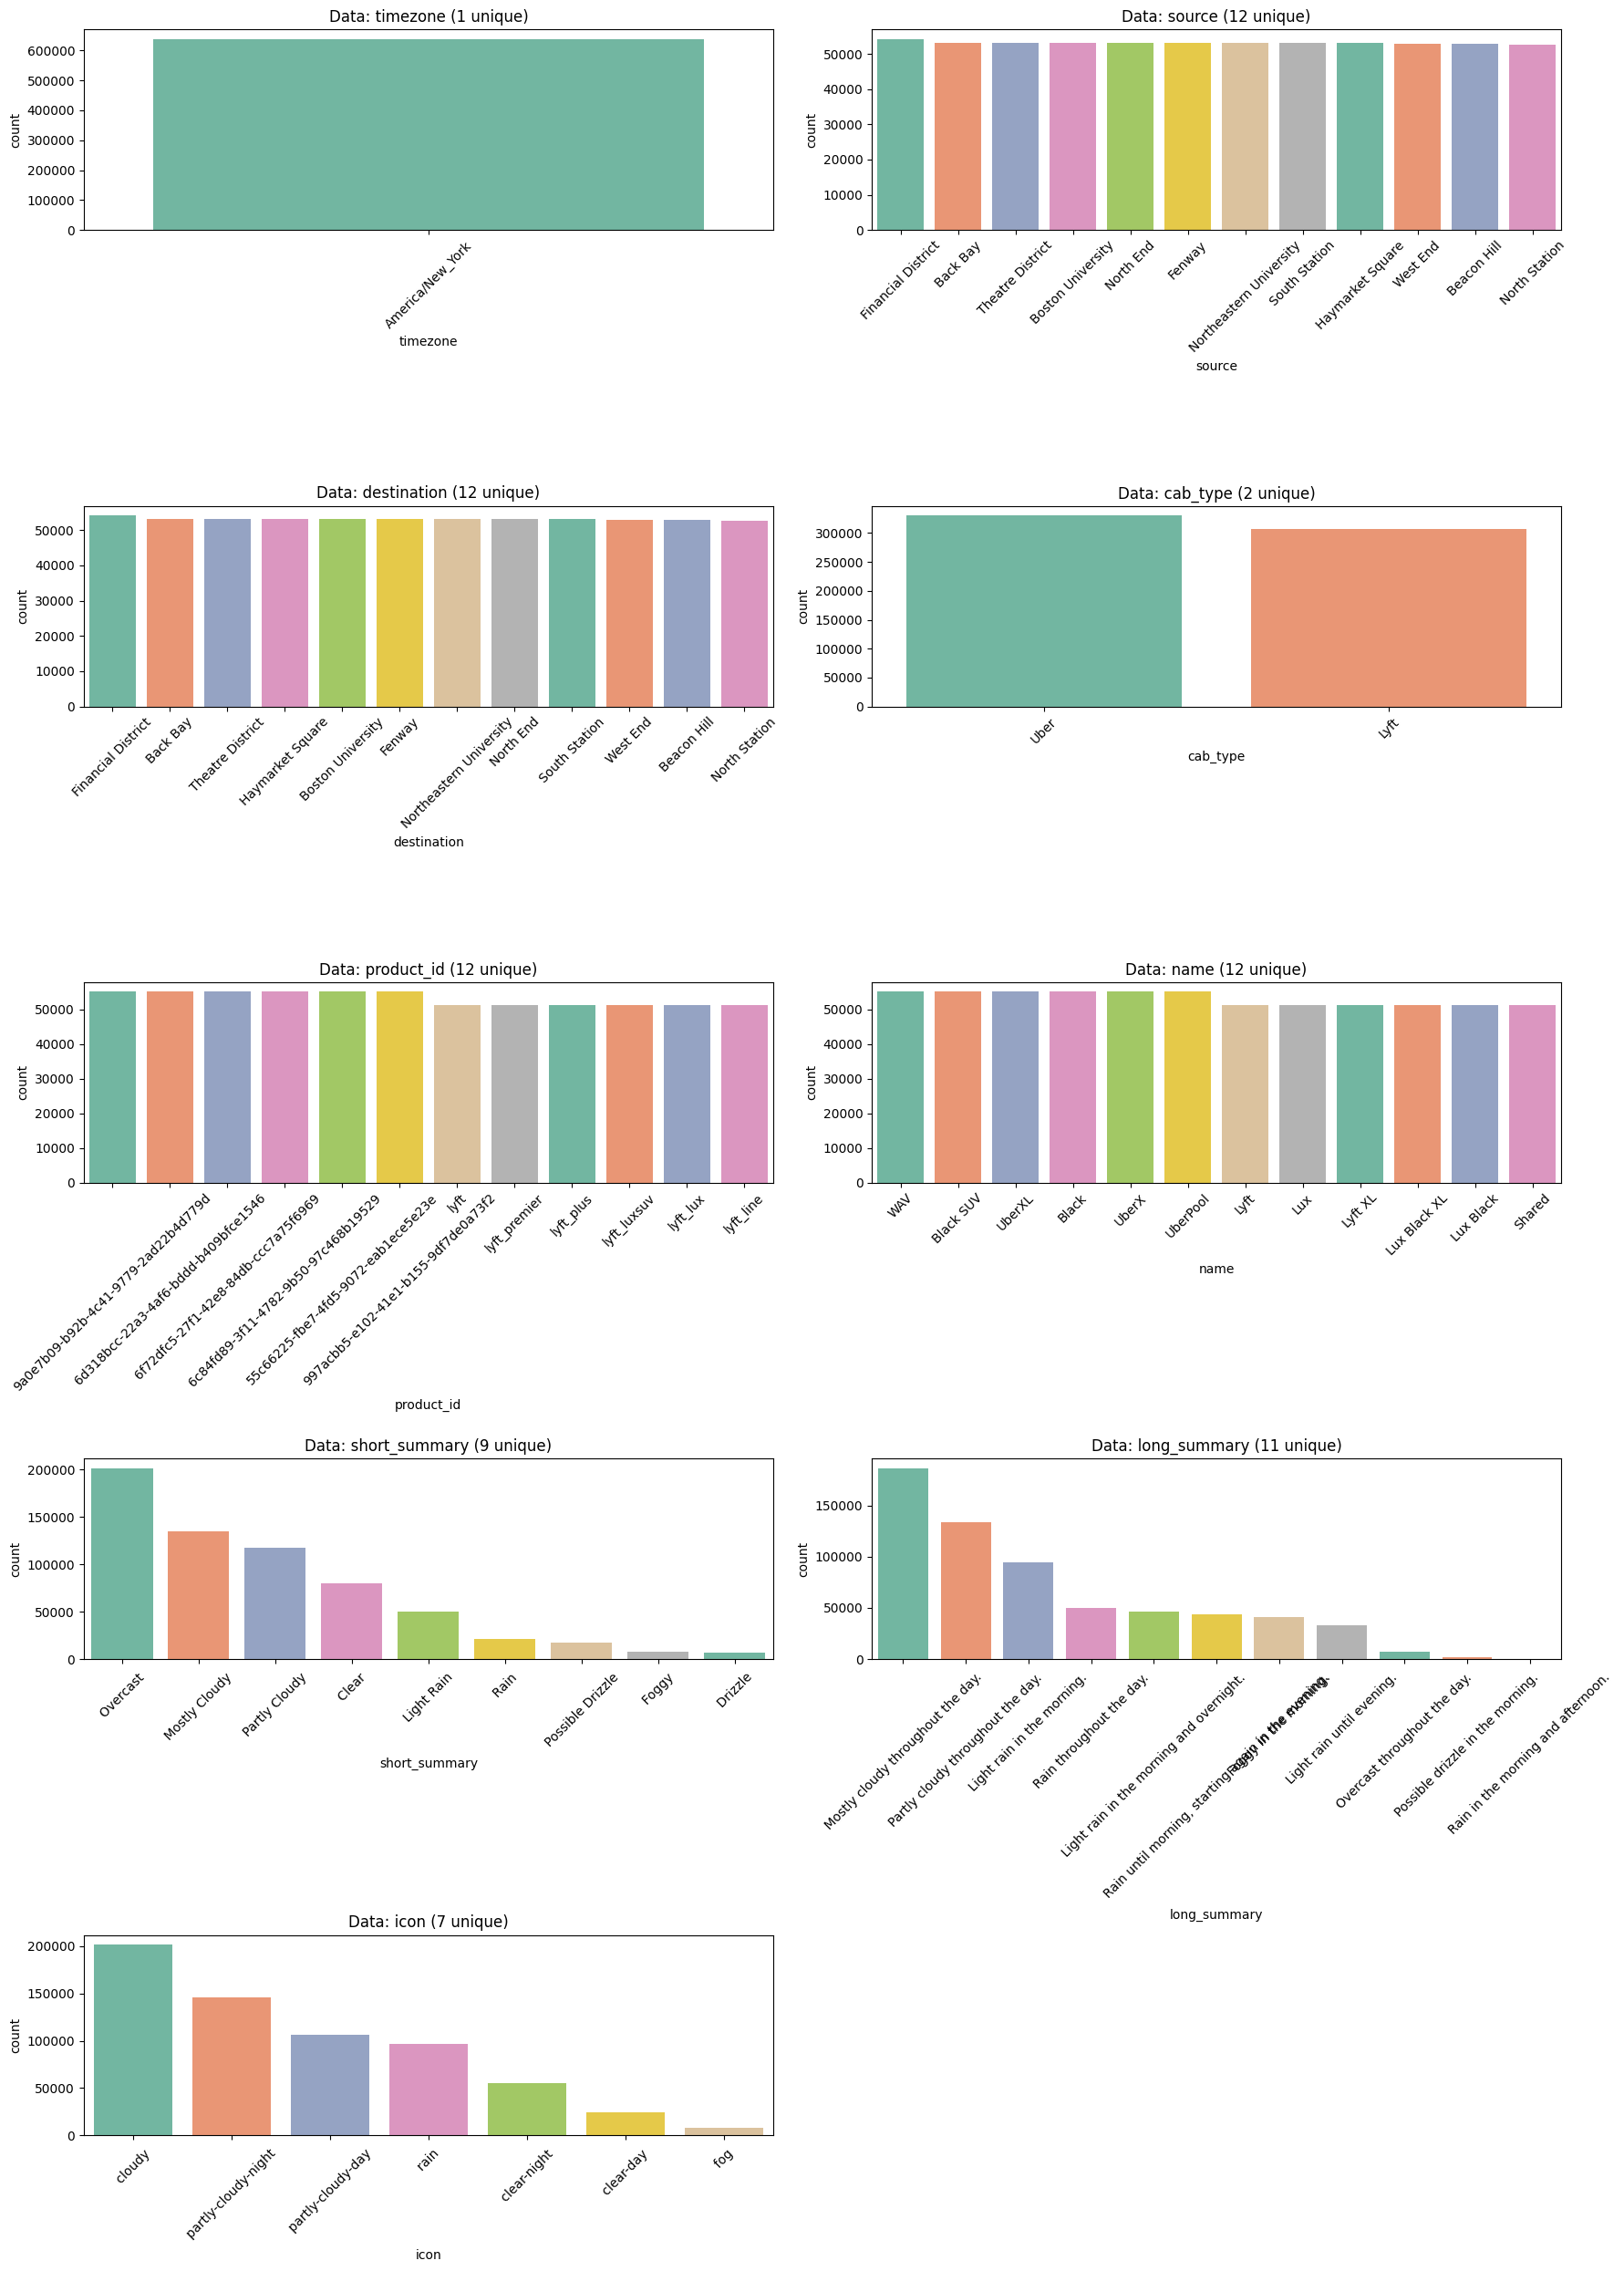

In [9]:
plot_dataset(df, cat_cols)

In [9]:
df = df.drop(columns=['timezone', 'cab_type', 'product_id', 'short_summary', 'icon'])
cat_cols = [col for col in cat_cols if col not in ['timezone', 'cab_type', 'product_id', 'short_summary', 'icon']]

In [ ]:
def plot_correlation_matrix(df, columns, title="Numerical Correlation Matrix"):

    corr = df[columns].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    dimension = 4 + (len(columns) * 0.6)
    plt.figure(figsize=(dimension, dimension))

    sns.heatmap(
        corr, 
        mask=mask, 
        annot=True,          
        fmt=".2f",           
        cmap='RdBu_r',       
        center=0,            
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .8}
    )

    plt.title(title, fontsize=16)
    plt.show()

In [ ]:
def find_correlated_groups(df, columns, threshold=0.90):

    corr_matrix = df[columns].corr().abs()
    
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    pairs = []
    for col in upper.columns:
        correlated_with = upper.index[upper[col] > threshold].tolist()
        for row in correlated_with:
            pairs.append((row, col))
            
    groups = []
    for a, b in pairs:
        found = False
        for g in groups:
            if a in g or b in g:
                g.update([a, b])
                found = True
                break
        if not found:
            groups.append({a, b})
            
    return groups

high_corr_groups = find_correlated_groups(df, num_cols)
print(f"{high_corr_groups}")

[{'temperatureLowTime', 'apparentTemperatureLowTime', 'windGustTime', 'sunriseTime', 'sunsetTime', 'uvIndexTime', 'temperatureMaxTime', 'timestamp', 'apparentTemperatureHighTime', 'temperatureHighTime', 'temperatureMinTime', 'apparentTemperatureMaxTime', 'apparentTemperatureMinTime', 'datetime'}, {'apparentTemperature', 'temperature'}, {'windSpeed', 'windGust'}, {'temperatureMax', 'apparentTemperatureMax', 'temperatureHigh', 'apparentTemperatureHigh'}, {'apparentTemperatureLow', 'temperatureLow'}, {'visibility.1', 'visibility'}, {'apparentTemperatureMin', 'temperatureMin'}]


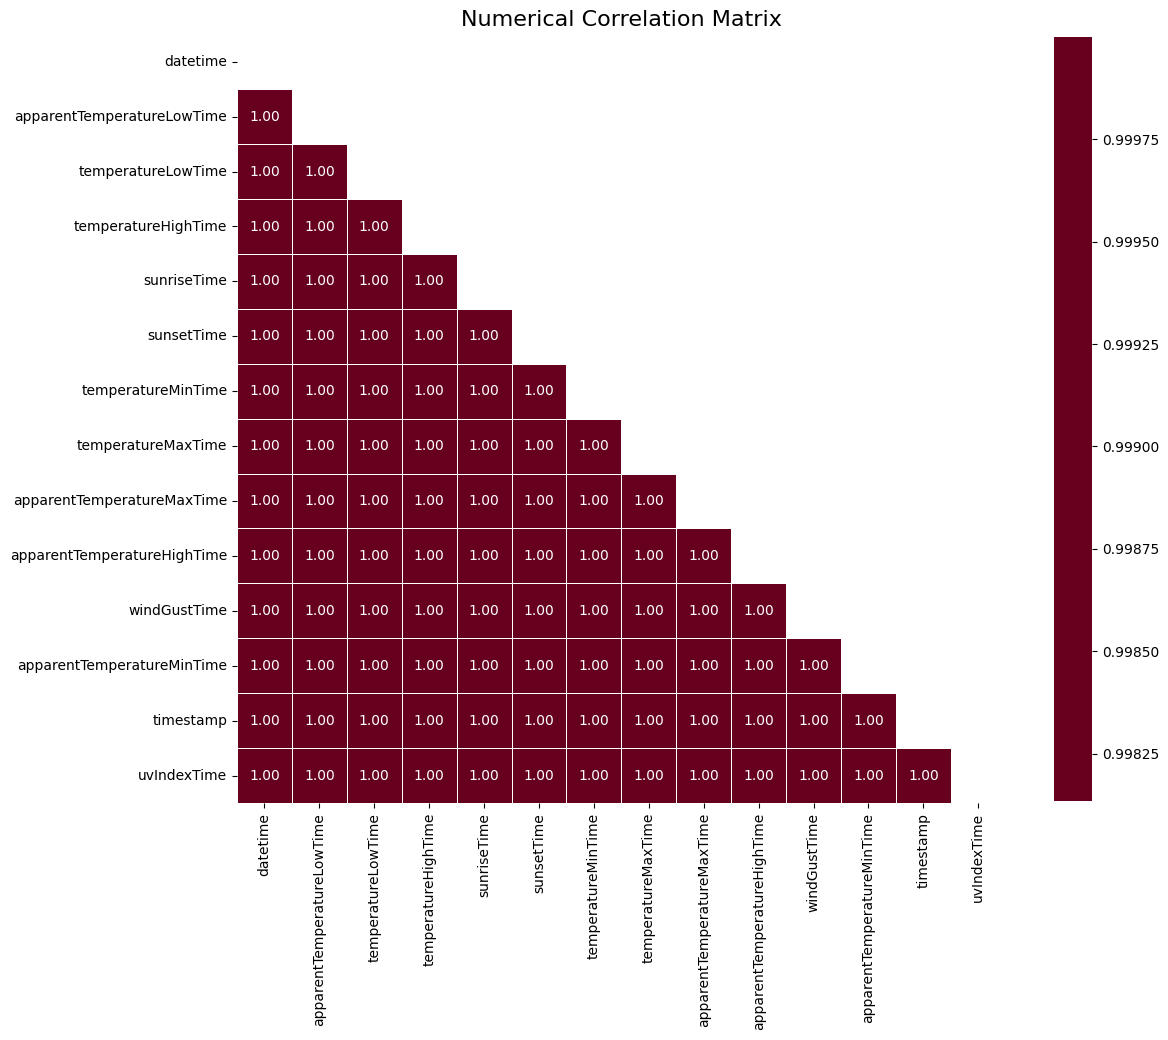

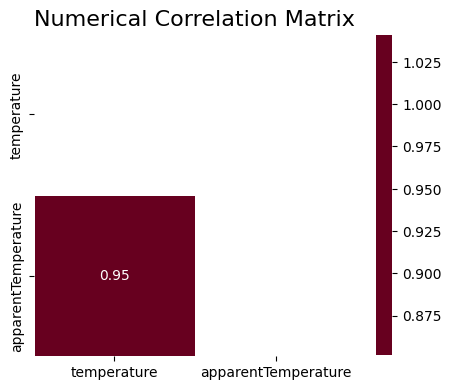

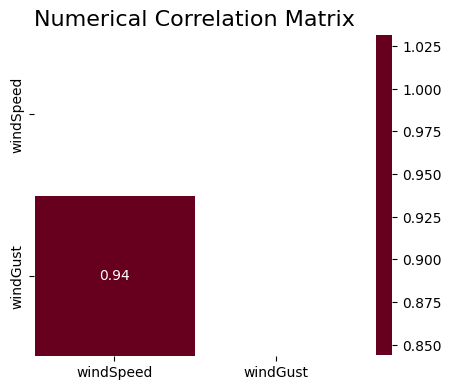

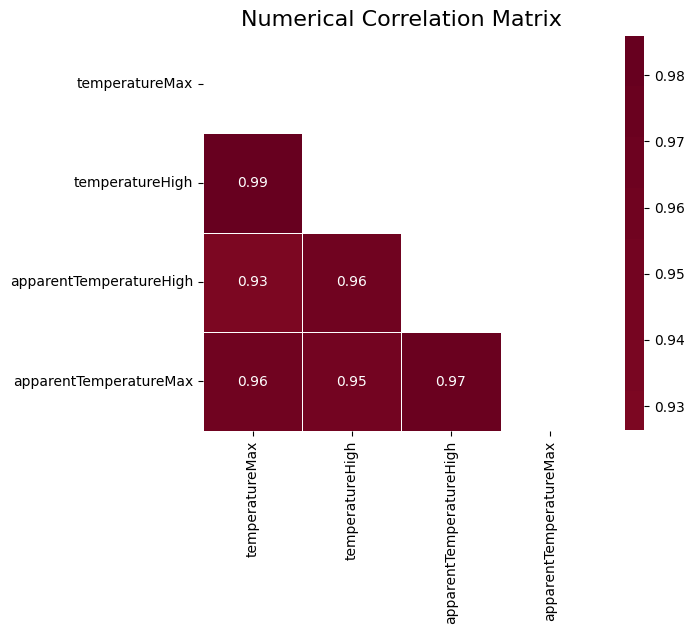

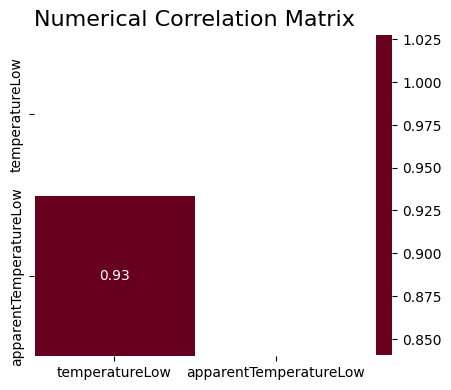

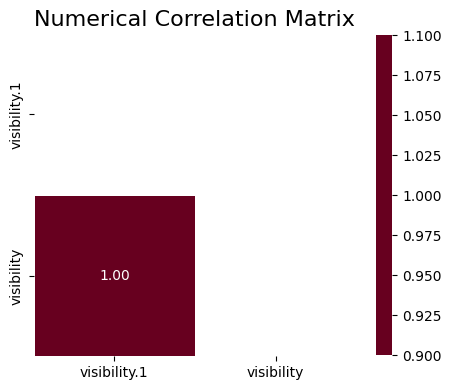

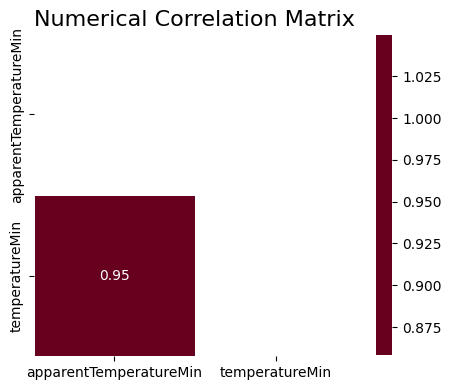

In [12]:
for group in high_corr_groups:
    plot_correlation_matrix(df, list(group))

In [12]:
cols_to_drop = []
for group in high_corr_groups:
    group_list = sorted(list(group)) 
    cols_to_drop.extend(group_list[1:])

df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} redundant columns.")
print(f"Remaining columns: {df.shape[1]}")

num_cols = [col for col in num_cols if col not in cols_to_drop]

Dropped 21 redundant columns.
Remaining columns: 31


In [13]:
def count_outliers_iqr(df, columns):
    outlier_report = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        if len(outliers) > 0:
            outlier_report[col] = len(outliers)
            
    return outlier_report

reports = count_outliers_iqr(df, num_cols)
print(reports)
outliers = reports.keys()

{'price': 5589, 'distance': 6672, 'surge_multiplier': 20975, 'latitude': 81570, 'apparentTemperature': 49208, 'precipIntensity': 138748, 'precipProbability': 138748, 'windGust': 15501, 'visibility': 125857, 'apparentTemperatureHigh': 65918, 'apparentTemperatureLow': 80708, 'dewPoint': 34331, 'uvIndex': 146770, 'apparentTemperatureMin': 70016}


In [ ]:
def plot_boxplots(df, num_cols):
    sns.set_theme(style="whitegrid")
    
    n_cols = 2
    n_rows = (len(num_cols) + 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col}')
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

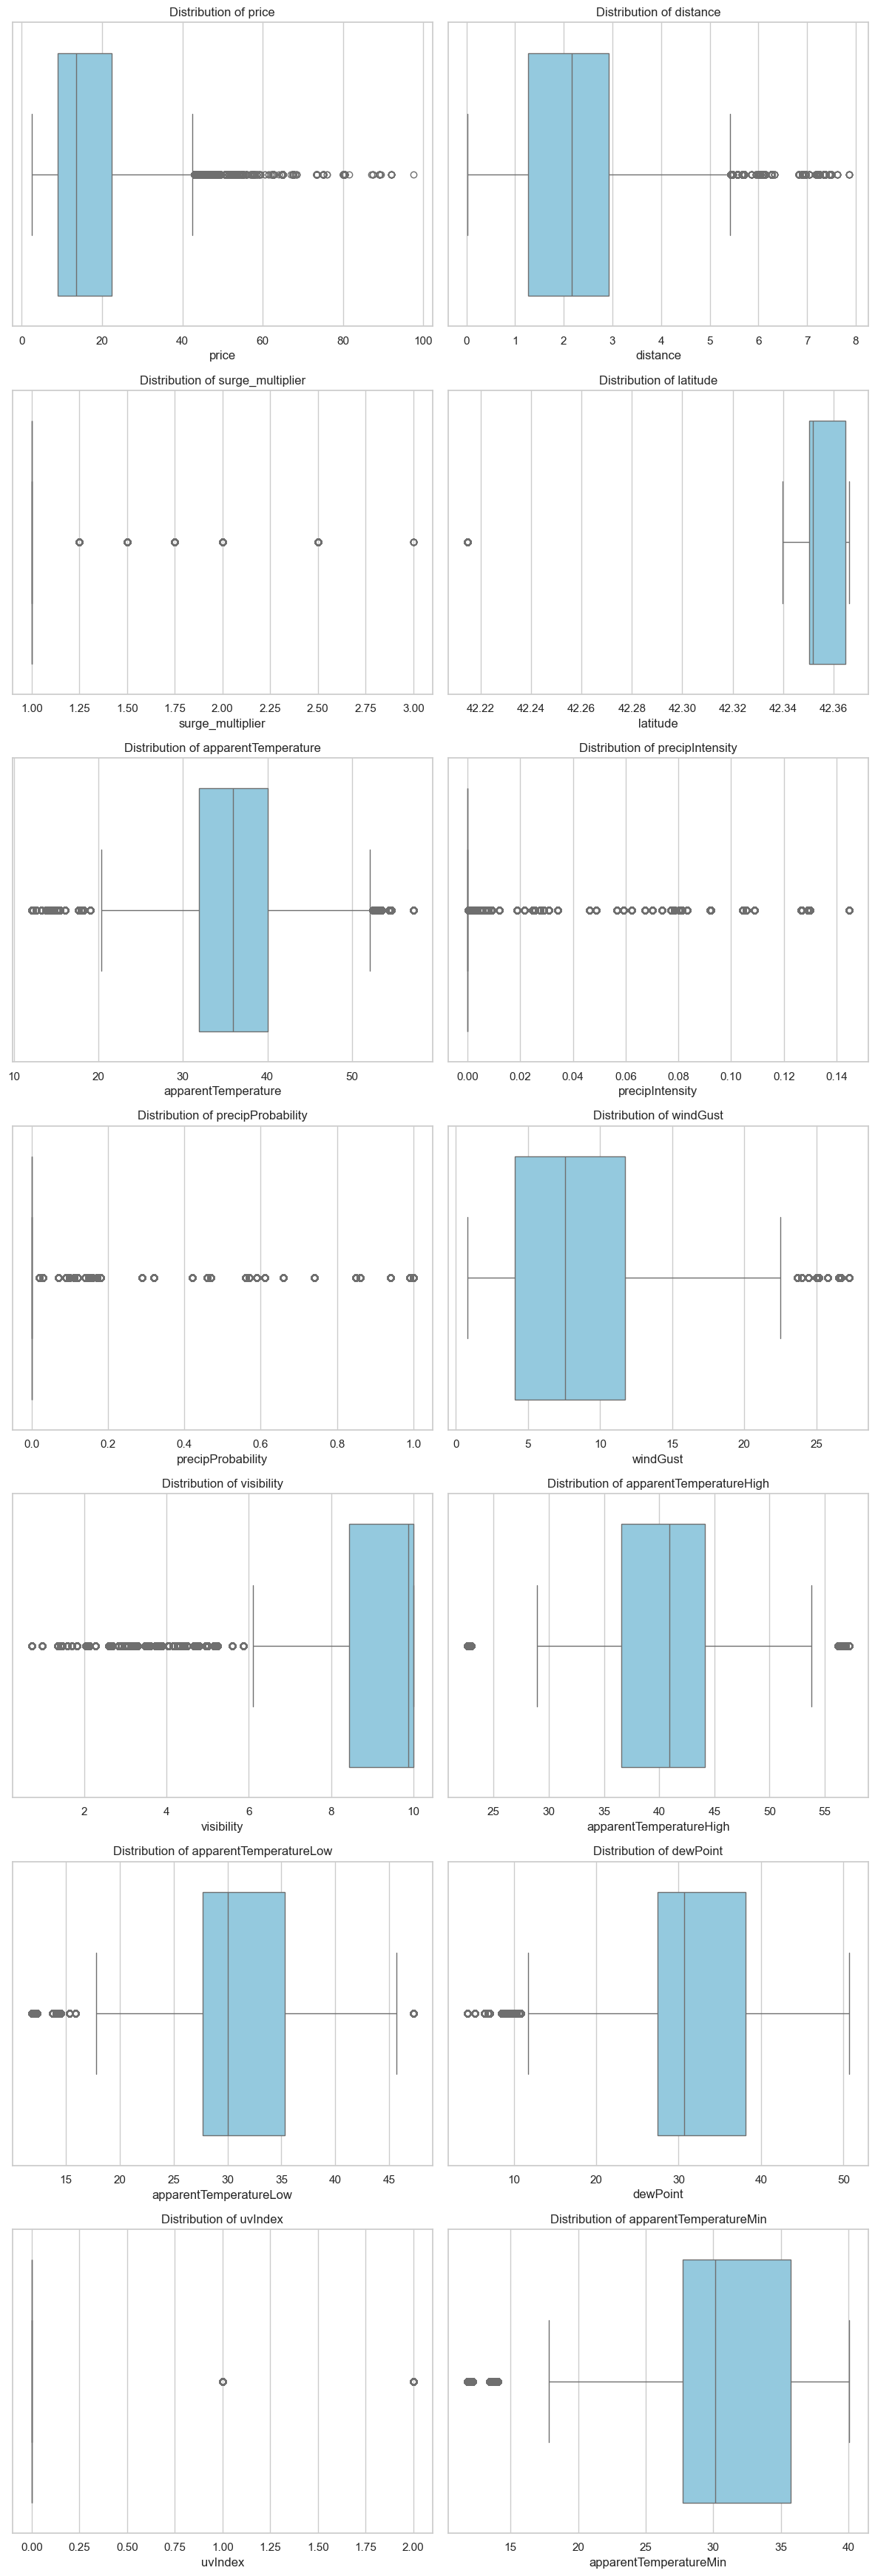

In [19]:
plot_boxplots(df, outliers)

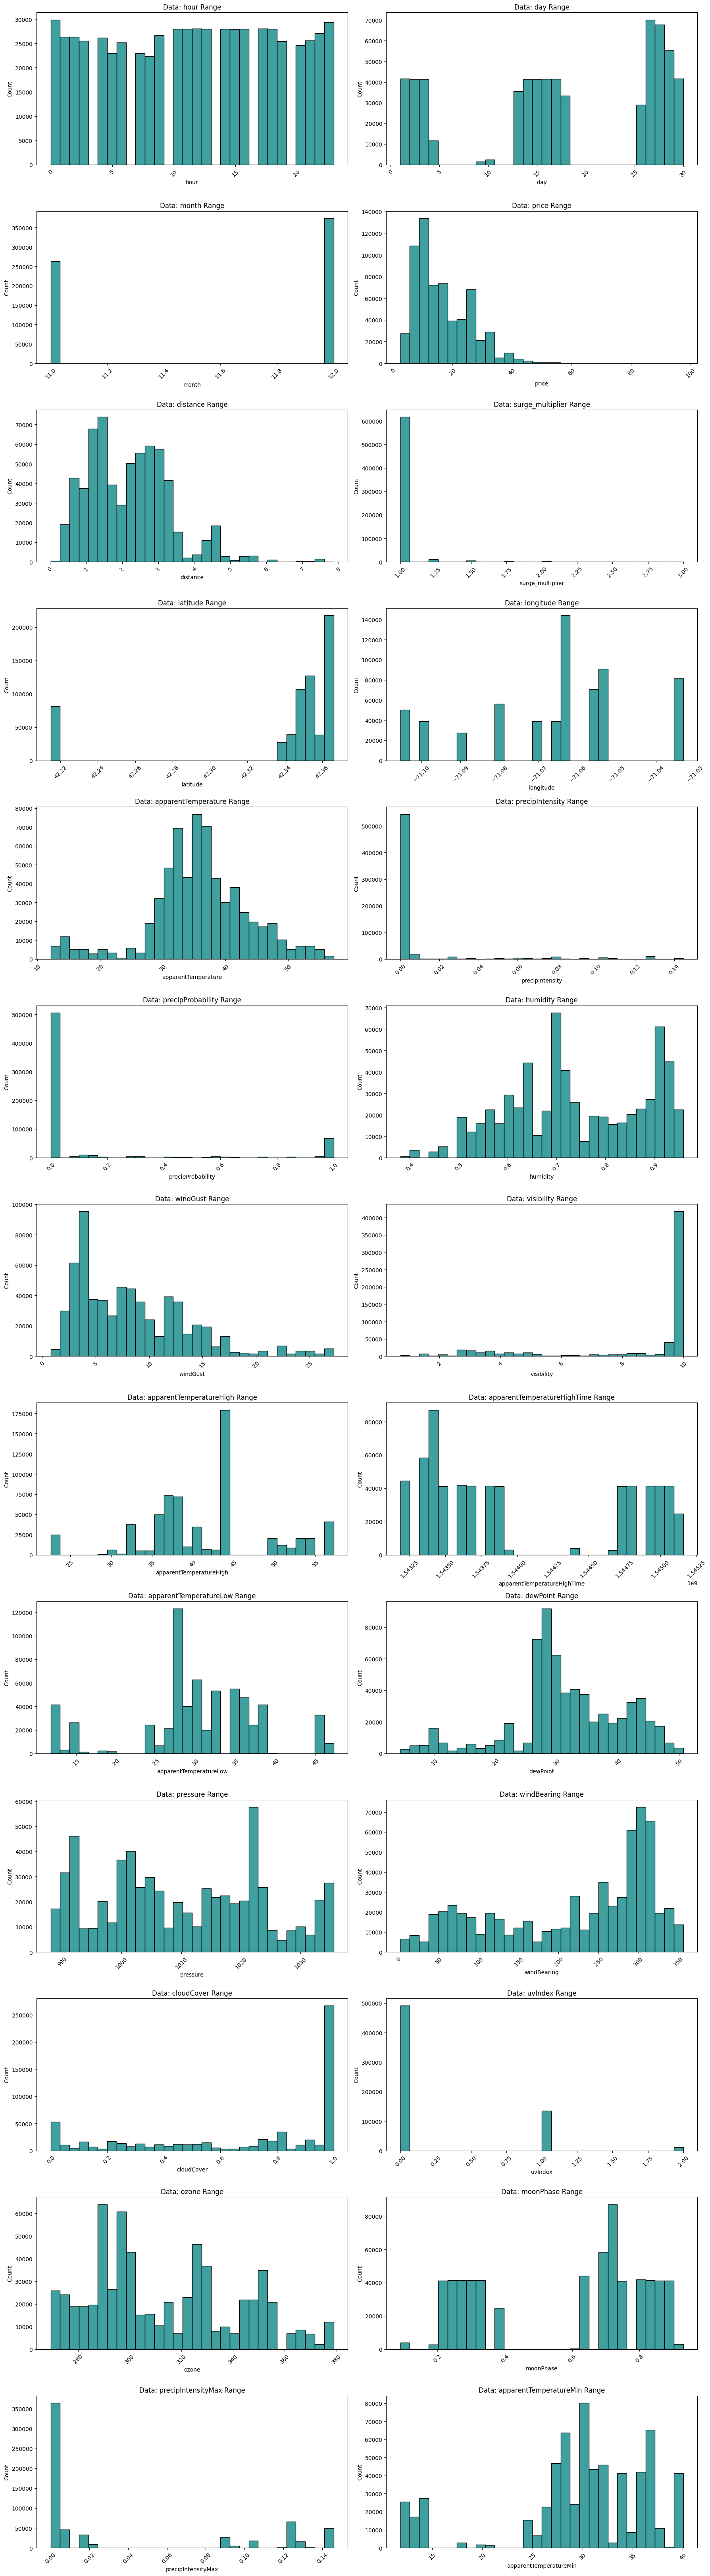

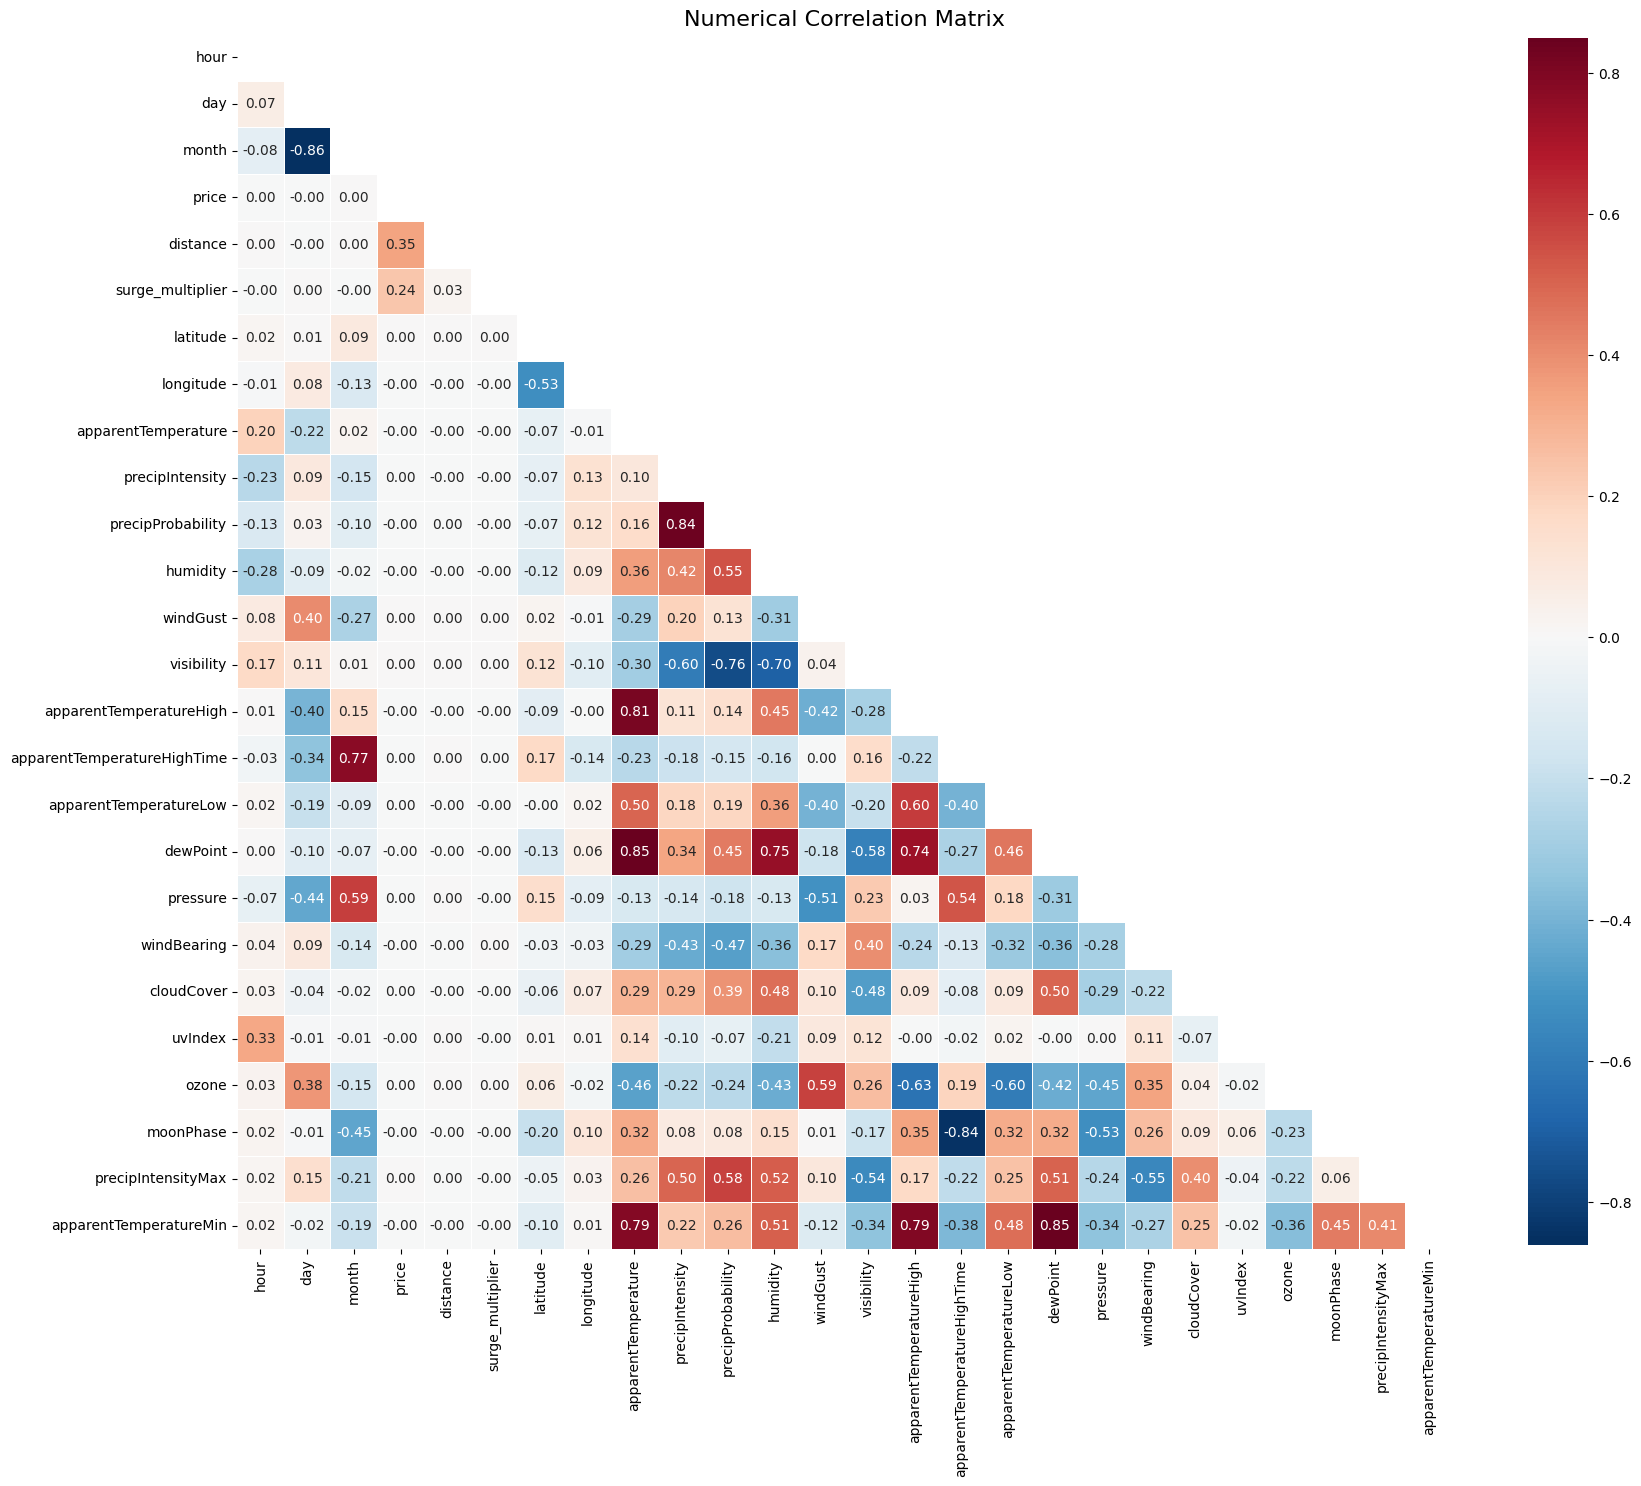

In [68]:
plot_dataset(df, num_cols)
plot_correlation_matrix(df, num_cols)

In [ ]:
# cols_to_drop = ['datetime', 'id', 'timestamp'] if 'id' in df.columns else ['datetime', 'timestamp']
cols_to_drop = ['id'] if 'id' in df.columns else []
df_model = df.drop(columns=cols_to_drop + ['price'], errors='ignore')
y = df['price']

cat_cols_model = [col for col in cat_cols if col not in cols_to_drop + ['price']]
num_cols_model = [col for col in num_cols if col not in cols_to_drop + ['price']]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_model)
    ])

X_train, X_test, y_train, y_test = train_test_split(df_model, y, test_size=0.2, random_state=42)

ZeroR Baseline Results:
Mean Price (prediction): $16.55
MAE: $7.56
RMSE: $9.34

Actual test set price stats:
Mean: $16.54
Std: $9.34
Min: $2.50
Max: $92.00


In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    rmse = root_mean_squared_error(y_test, y_pred) 
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} Results:")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    
    return rmse, r2

In [117]:
mean_price = y_train.mean()
y_pred_baseline = [mean_price] * len(y_test)

rmse_baseline = root_mean_squared_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"ZeroR Baseline Results:")
print(f"Mean Price (prediction): ${mean_price:.2f}")
print(f"RMSE: ${rmse_baseline:.2f}")
print(f"R2: {r2_baseline:.2f}")

print(f"\nActual test set price stats:")
print(f"Mean: ${y_test.mean():.2f}")
print(f"Std: ${y_test.std():.2f}")
print(f"Min: ${y_test.min():.2f}")
print(f"Max: ${y_test.max():.2f}")

ZeroR Baseline Results:
Mean Price (prediction): $16.55
RMSE: $9.34
R2: -0.00

Actual test set price stats:
Mean: $16.54
Std: $9.34
Min: $2.50
Max: $92.00


In [108]:
# 3. AdaBoost
lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_jobs=-1, random_state=42))
])

lgb_pipeline.fit(X_train, y_train)
evaluate_model(lgb_pipeline, X_test, y_test, "LightGBM")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2789
[LightGBM] [Info] Number of data points in the train set: 510380, number of used features: 72
[LightGBM] [Info] Start training from score 16.545838

LightGBM Results:
RMSE: $1.67
R2 Score: 0.9679


c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


(1.6736759588474, 0.9678690337608112)

In [22]:
def cross_validate_model(pipeline, size = -1):
    cv_results = cross_validate(
        pipeline, X_train[:size], y_train[:size], 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        return_train_score=True, 
        n_jobs=-1 
    )

    train_rmse = -cv_results['train_score'].mean()
    val_rmse = -cv_results['test_score'].mean()
    val_std = cv_results['test_score'].std() 

    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Validation RMSE: {val_rmse:.2f} (+/- {val_std:.2f})")

def plot_learning_curve(pipeline, linspace):
    train_sizes, train_scores, test_scores = learning_curve(
        pipeline, X_train, y_train, 
        cv=5, 
        scoring='neg_root_mean_squared_error', 
        train_sizes=linspace, #start at 10% of data, end at 100%, with 10 divisions (so increment by 10%)
        n_jobs=-1
    )

    train_mean = -np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = -np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training Error', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, test_mean, label='Validation Error', color='green', marker='s')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

    plt.title('Learning Curves (Diagnosis for Bias vs. Variance)')
    plt.xlabel('Training Set Size')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.show()

def custom_learning_curve(pipeline, fractions, cv = 5):    
    train_means, train_stds = [], []
    val_means, val_stds = [], []
    sample_sizes = []
    
    n_total = len(X_train)

    for frac in fractions:
        size = int(frac * n_total)
        # Skip if the subset is too small for the requested CV folds
        if size < cv:
            continue
        
        sample_sizes.append(size)
        
        # Slicing the data
        X_subset = X_train.iloc[:size] if hasattr(X_train, 'iloc') else X_train[:size]
        y_subset = y_train.iloc[:size] if hasattr(y_train, 'iloc') else y_train[:size]
        
        # Manual Cross-Validation
        cv_results = cross_validate(
            pipeline, X_subset, y_subset,
            cv=cv,
            scoring='neg_root_mean_squared_error',
            return_train_score=True,
            n_jobs=-1
        )
        
        # Convert negative RMSE to positive
        train_means.append(-np.mean(cv_results['train_score']))
        train_stds.append(np.std(cv_results['train_score']))
        val_means.append(-np.mean(cv_results['test_score']))
        val_stds.append(np.std(cv_results['test_score']))

    plt.figure(figsize=(10, 6))
    plt.plot(sample_sizes, train_means, label='Train RMSE', color='blue', marker='o')
    plt.fill_between(sample_sizes, np.array(train_means) - np.array(train_stds), 
                    np.array(train_means) + np.array(train_stds), alpha=0.1, color='blue')
    
    plt.plot(sample_sizes, val_means, label='Val RMSE', color='green', marker='s')
    plt.fill_between(sample_sizes, np.array(val_means) - np.array(val_stds), 
                    np.array(val_means) + np.array(val_stds), alpha=0.1, color='green')

    plt.title('Learning Curve')
    plt.xlabel('Number of Training Samples')
    plt.ylabel('RMSE')
    plt.legend()
    plt.grid(True)
    plt.show()

 

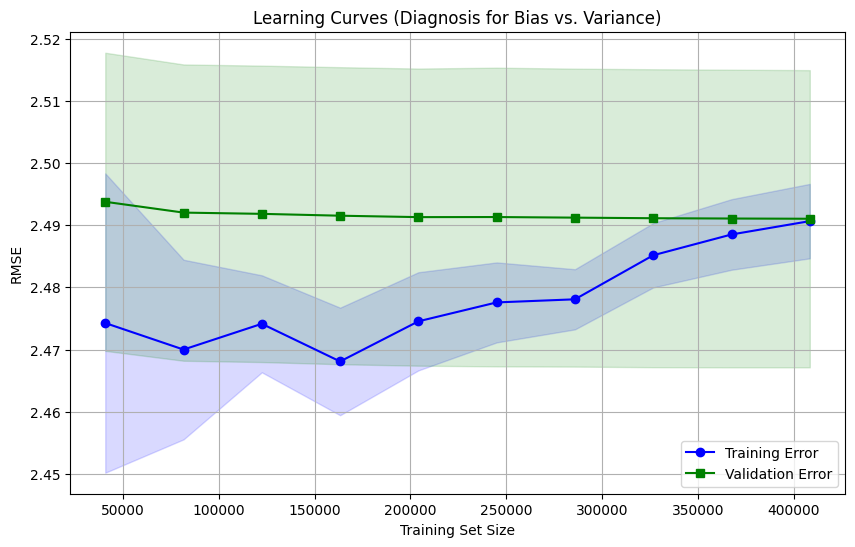

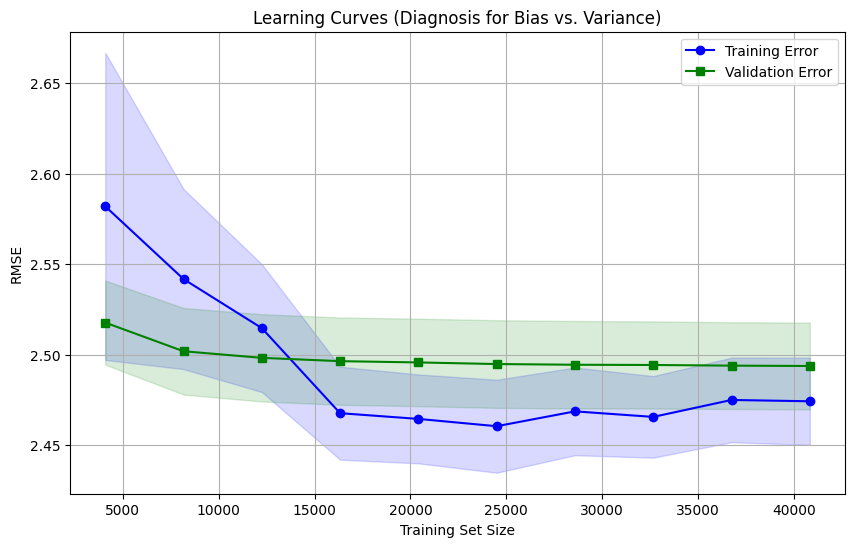

In [24]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
plot_learning_curve(lr_pipeline, np.linspace(0.1, 1, 10))
plot_learning_curve(lr_pipeline, np.linspace(0.01, 0.1, 10))

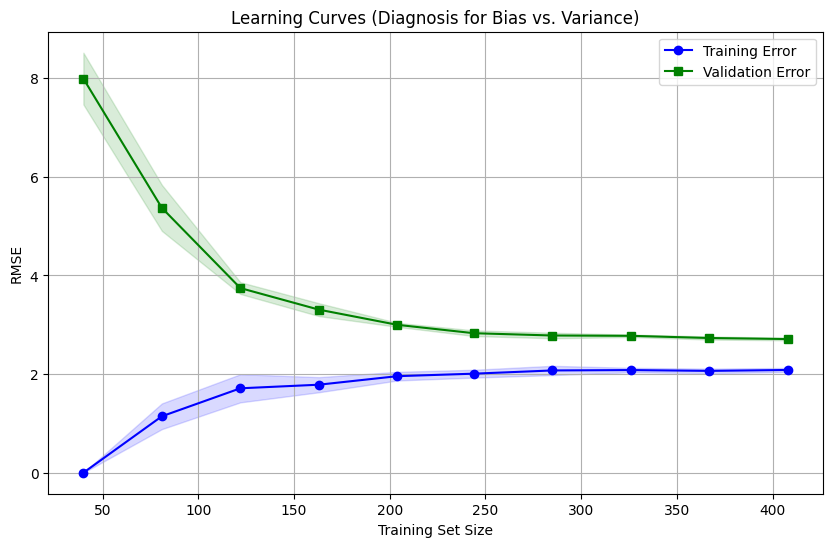

In [24]:
plot_learning_curve(lr_pipeline, np.linspace(0.0001, 0.001, 10))

In [25]:
cross_validate_model(lr_pipeline)

Training RMSE: 2.49
Validation RMSE: 2.49 (+/- 0.02)


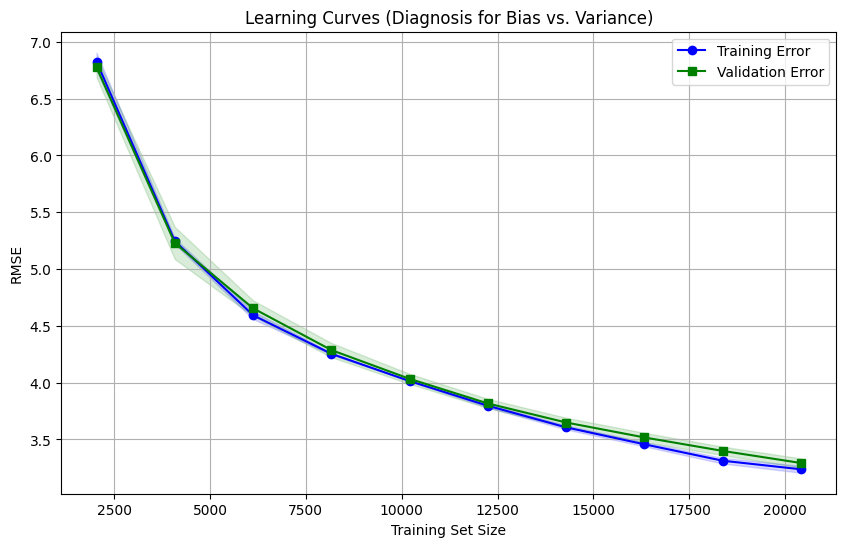

In [ ]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])
plot_learning_curve(svm_pipeline, np.linspace(0.005, 0.05, 10))

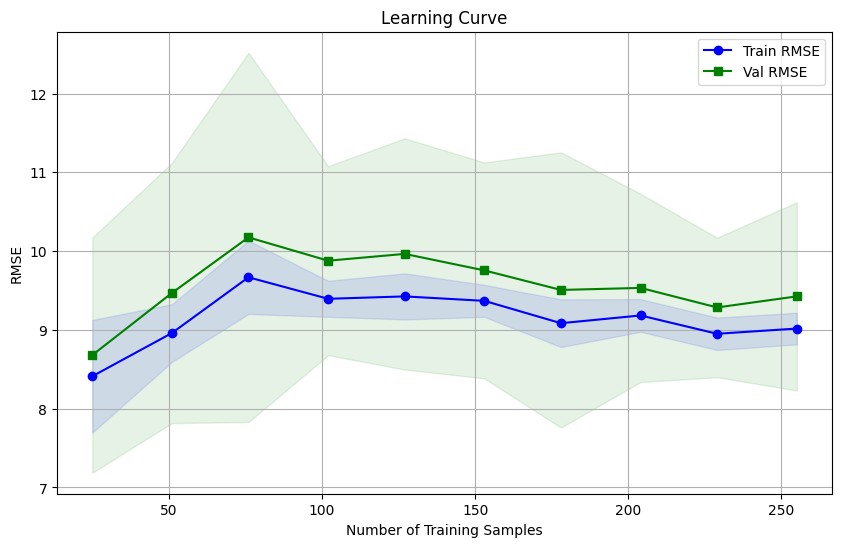

In [42]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

custom_learning_curve(svm_pipeline, np.linspace(0.00005, 0.0005, 10))

In [58]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=100.0, epsilon=0.1))
])
# custom_learning_curve(svm_pipeline, np.linspace(0.0005, 0.005, 10))
cross_validate_model(svm_pipeline, 20000)


Training RMSE: 1.47
Validation RMSE: 2.05 (+/- 0.12)


In [59]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=50.0, epsilon=0.1))
])
# custom_learning_curve(svm_pipeline, np.linspace(0.0005, 0.005, 10))
cross_validate_model(svm_pipeline, 20000)

Training RMSE: 1.65
Validation RMSE: 2.07 (+/- 0.12)


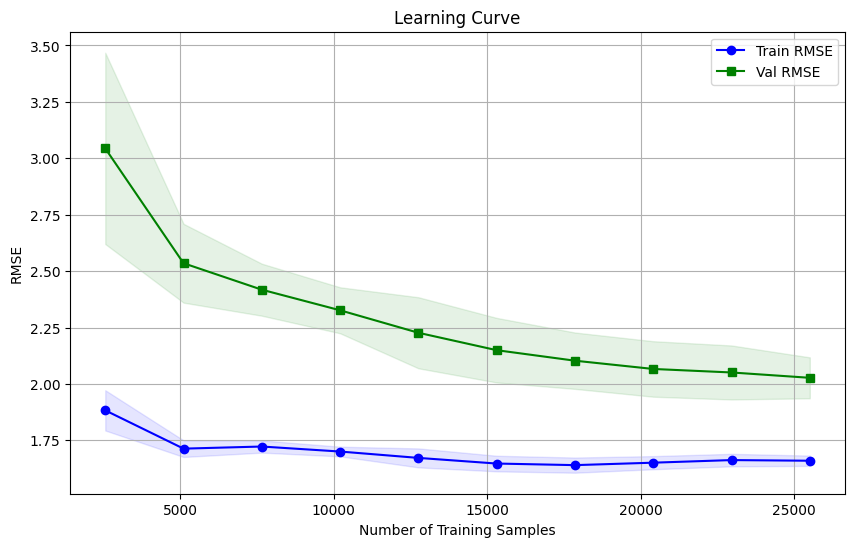

In [67]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=50.0, epsilon=0.1))
])
custom_learning_curve(svm_pipeline, np.linspace(0.005, 0.05, 10))
# cross_validate_model(svm_pipeline, 20000)

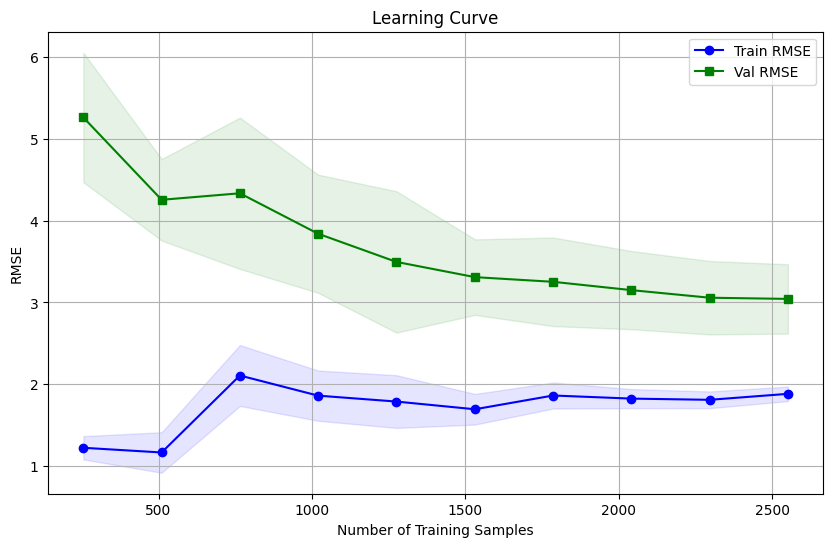

In [63]:
custom_learning_curve(svm_pipeline, np.linspace(0.0005, 0.005, 10))

In [29]:
cross_validate_model(svm_pipeline, 4000)

Training RMSE: 6.01
Validation RMSE: 6.16 (+/- 0.39)


In [27]:
cross_validate_model(svm_pipeline, 50000)


Training RMSE: 2.73
Validation RMSE: 2.77 (+/- 0.06)


In [ ]:
plot_learning_curve(svm_pipeline, np.linspace(0.005, 0.05, 10))
cross_validate_model(svm_pipeline, 100000)


Training RMSE: 2.48
Validation RMSE: 2.51 (+/- 0.02)


In [48]:
bagging_svm = BaggingRegressor(
    estimator=SVR(kernel='rbf', C=10, epsilon=0.1),
    n_estimators=10, 
    max_samples=0.1,  # 10% of 500k = 50k rows per model (RAM friendly!)
    bootstrap=True,
    n_jobs=-1         # Runs them in parallel
)

svm_bagging_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', bagging_svm)
])

# plot_learning_curve(svm_pipeline, np.linspace(0.005, 0.05, 10))
cross_validate_model(svm_bagging_pipeline, 20000)

Training RMSE: 3.60
Validation RMSE: 3.68 (+/- 0.15)


In [ ]:
def validate_model_fixed_split(pipeline, train_size = -1, test_size=0.2, random_state=42):
    X_sub_train, X_val, y_sub_train, y_val = train_test_split(
        X_train[:train_size], y_train[:train_size], test_size=test_size, random_state=random_state
    )

    # 2. Fit the pipeline on the sub-train set
    pipeline.fit(X_sub_train, y_sub_train)

    # 3. Predict
    train_preds = pipeline.predict(X_sub_train)
    val_preds = pipeline.predict(X_val)

    # 4. Calculate RMSE
    train_rmse = root_mean_squared_error(y_sub_train, train_preds)
    val_rmse = root_mean_squared_error(y_val, val_preds)

    print(f"Training RMSE: {train_rmse:.2f}")
    print(f"Validation RMSE: {val_rmse:.2f}")
    
    return train_rmse, val_rmse

In [103]:
estimators = [
    ('polynomial', Pipeline([
        ('poly', PolynomialFeatures(degree=2)), 
        ('regressor', LinearRegression())       
    ])),
    ('complex_svm', SVR(kernel='rbf', C=50, epsilon=0.1)),
]


stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=10), # Blends the predictions
        cv=3, 
        n_jobs=-1
    ))
])

# cross_validate_model(stacking_pipeline, 5000)
#1.83 #2.41


In [105]:
validate_model_fixed_split(stacking_pipeline, 5000)

Training RMSE: 1.53
Validation RMSE: 2.25


(1.5279112422596983, 2.247572158867448)

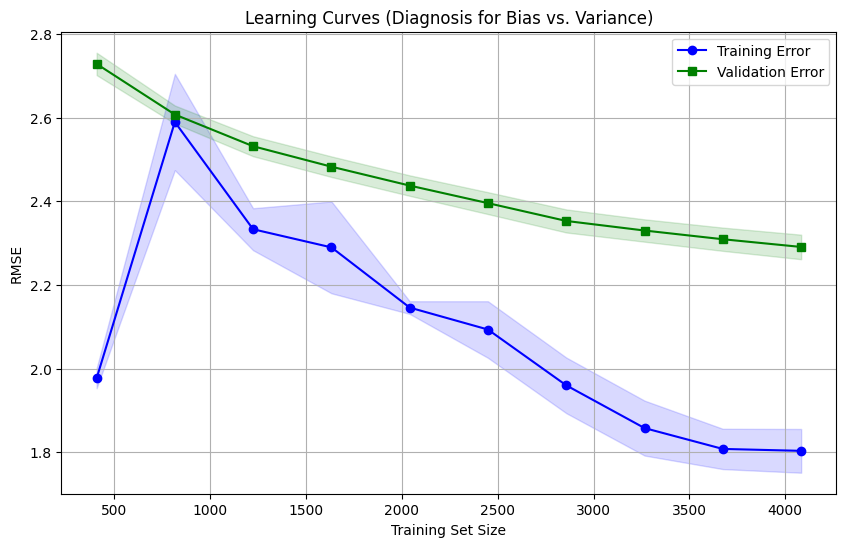

In [58]:
plot_learning_curve(stacking_pipeline, np.linspace(0.001, 0.01, 10))

In [61]:
from sklearn.base import BaseEstimator, RegressorMixin, clone

class ResidualBooster(BaseEstimator, RegressorMixin):
    def __init__(self, base_estimator, boosting_estimator):
        self.base_estimator = base_estimator
        self.boosting_estimator = boosting_estimator
        
    def fit(self, X, y):
        # 1. Fit the base model (Linear Regression)
        self.base_est_ = clone(self.base_estimator)
        self.base_est_.fit(X, y)
        
        # 2. Calculate residuals
        base_preds = self.base_est_.predict(X)
        residuals = y - base_preds
        
        # 3. Fit the booster (SVM) on residuals
        self.boosting_est_ = clone(self.boosting_estimator)
        self.boosting_est_.fit(X, residuals)
        return self
        
    def predict(self, X):
        # Final Prediction = Base + Correction
        return self.base_est_.predict(X) + self.boosting_est_.predict(X)

# --- Put it in the Pipeline ---

# Define your two stages
lr_base = LinearRegression()
svm_correction = SVR(kernel='rbf', C=1, epsilon=0.01)

# Create the final pipeline
boosting_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', ResidualBooster(base_estimator=lr_base, boosting_estimator=svm_correction))
])

cross_validate_model(boosting_pipeline, 5000)
# Now you can use it like any other model
# boosting_pipeline.fit(X_train, y_train)


Training RMSE: 2.49
Validation RMSE: 2.61 (+/- 0.10)


In [66]:
# 1. Define your stacker (the one that worked well but overfit)
stacker = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3 # Keep internal CV low to save time when bagging
)

# 2. Wrap it in Bagging to force convergence
bagged_stacker = BaggingRegressor(
    estimator=stacker,
    n_estimators=10,   # 10 is usually the sweet spot
    max_samples=0.7,    # Each "bag" sees 70% of data to keep it complex
    bootstrap=True,
    n_jobs=-1          
)

# 3. Final Pipeline
bagged_stacking_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', bagged_stacker)
])


cross_validate_model(bagged_stacking_pipeline, 5000)

Training RMSE: 2.21
Validation RMSE: 2.50 (+/- 0.11)


In [ ]:
linear_svm_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('regressor', )
])

cross_validate_model(linear_svm_pipeline)

Training RMSE: 2.49
Validation RMSE: 2.49 (+/- 0.02)


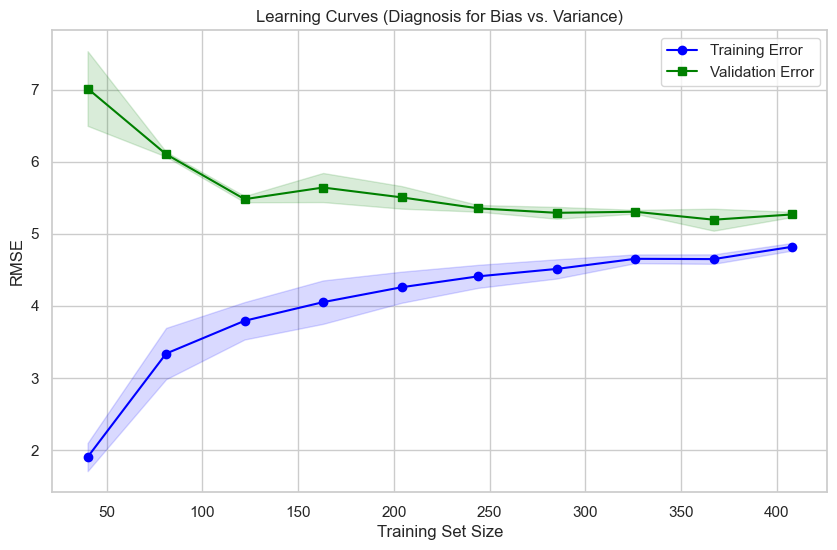

In [40]:
adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=100, learning_rate=1.0, random_state=42))
])
# cross_validate_model(adaboost_pipeline, 500)
plot_learning_curve(adaboost_pipeline, np.linspace(0.0001, 0.001, 10))

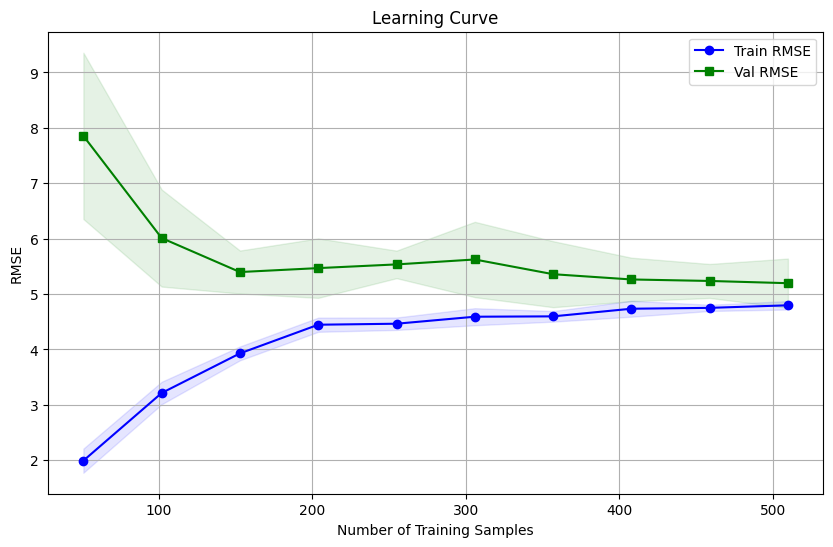

In [92]:
adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=100, learning_rate=1.0, random_state=42))
])
# cross_validate_model(adaboost_pipeline, 500)
custom_learning_curve(adaboost_pipeline, np.linspace(0.0001, 0.001, 10))

In [94]:
cross_validate_model(adaboost_pipeline, 500)

Training RMSE: 4.72
Validation RMSE: 5.13 (+/- 0.50)


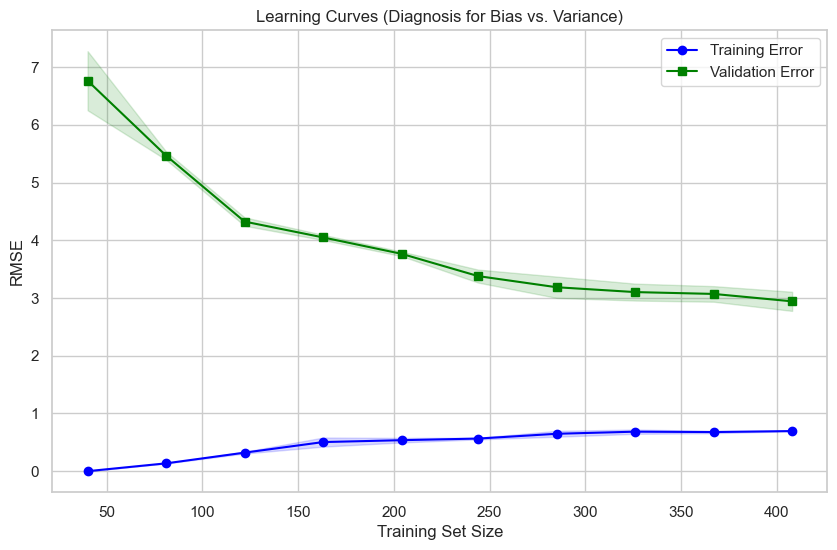

In [ ]:
base_learner = DecisionTreeRegressor(max_depth=10) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42, estimator=base_learner))
])
# cross_validate_model(adaboost_pipeline, 500)
plot_learning_curve(adaboost_pipeline, np.linspace(0.0001, 0.001, 10))

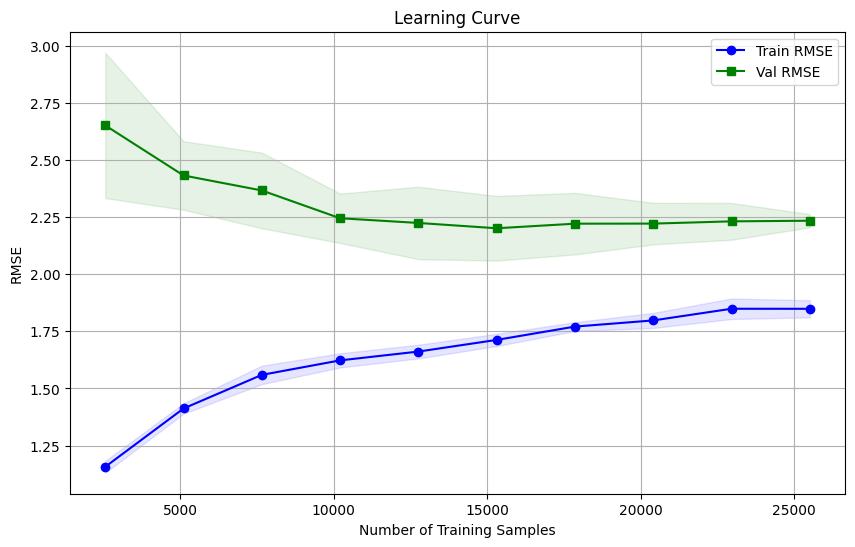

In [90]:
base_learner = DecisionTreeRegressor(max_depth=10) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42, estimator=base_learner))
])
# cross_validate_model(adaboost_pipeline, 500)
custom_learning_curve(adaboost_pipeline, np.linspace(0.005, 0.05, 10))

In [96]:
base_learner = DecisionTreeRegressor(max_depth=10) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42, estimator=base_learner))
])

cross_validate_model(adaboost_pipeline, 50000)

Training RMSE: 1.88
Validation RMSE: 2.14 (+/- 0.03)


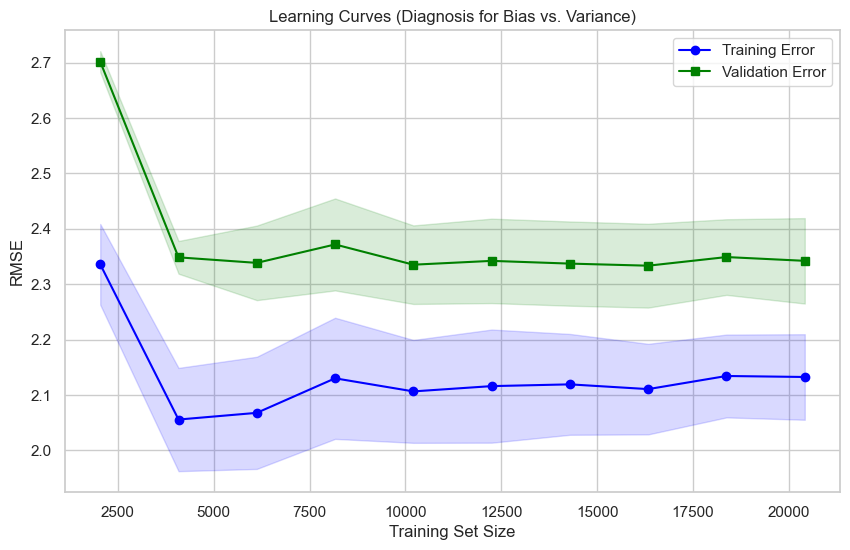

In [48]:
base_learner = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42, estimator=base_learner))
])
# cross_validate_model(adaboost_pipeline, 10000)
plot_learning_curve(adaboost_pipeline, np.linspace(0.005, 0.05, 10))

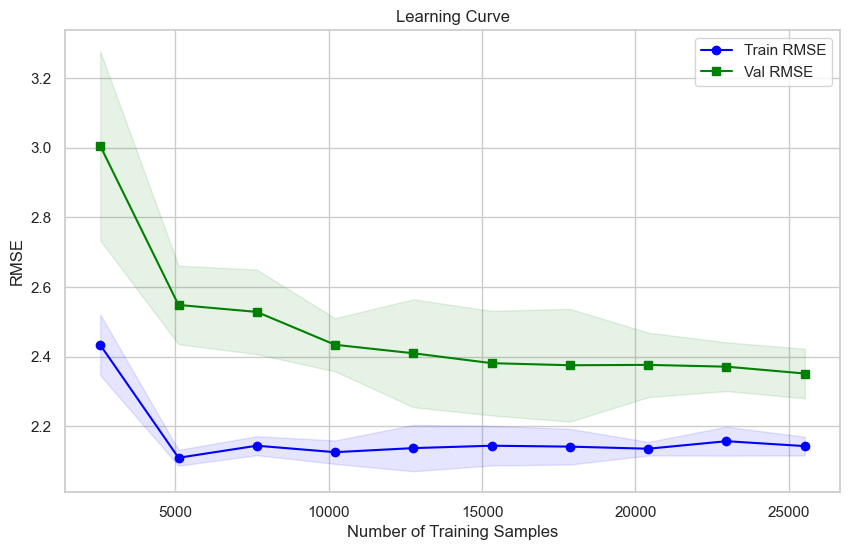

In [69]:
base_learner = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=200, learning_rate=0.1, random_state=42, estimator=base_learner))
])
# cross_validate_model(adaboost_pipeline, 10000)
custom_learning_curve(adaboost_pipeline, np.linspace(0.005, 0.05, 10))

In [86]:
base_learner = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50) 

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=400, learning_rate=0.1, random_state=42, estimator=base_learner))
])
cross_validate_model(adaboost_pipeline, 100000)
# custom_learning_curve(adaboost_pipeline, np.linspace(0.005, 0.05, 10))

KeyboardInterrupt: 

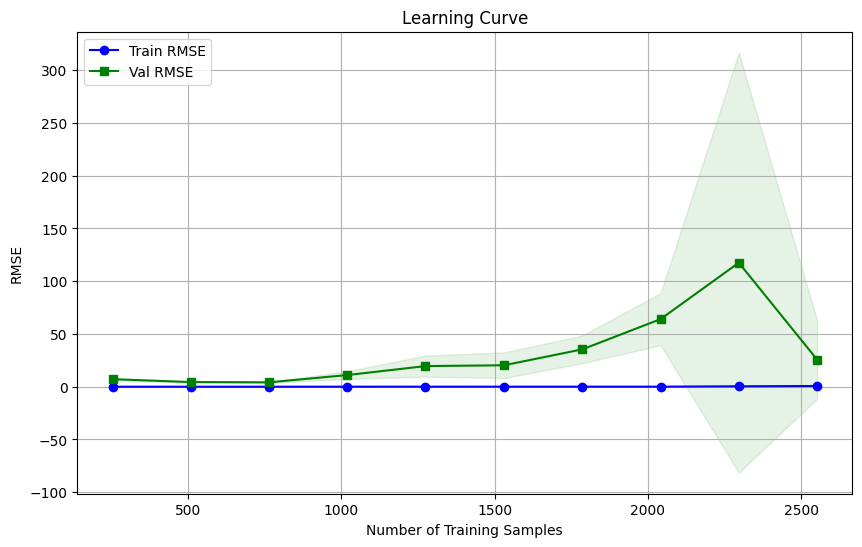

In [27]:
overfit_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)), 
    ('regressor', LinearRegression())       
])

# plot_learning_curve(overfit_poly, np.linspace(0.00005, 0.0005, 10))
custom_learning_curve(overfit_poly, np.linspace(0.0005, 0.005, 10))

# cross_validate_model(overfit_poly, 500)

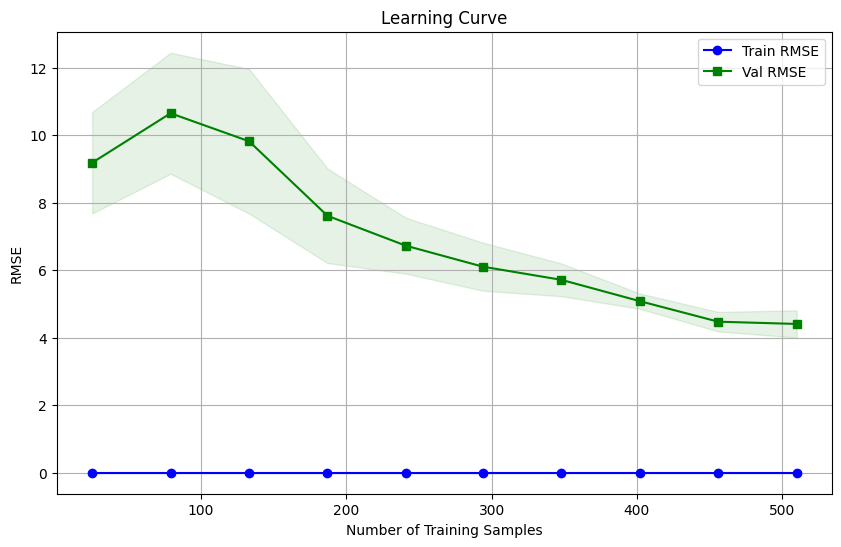

In [31]:
custom_learning_curve(overfit_poly, np.linspace(0.00005, 0.001, 10))

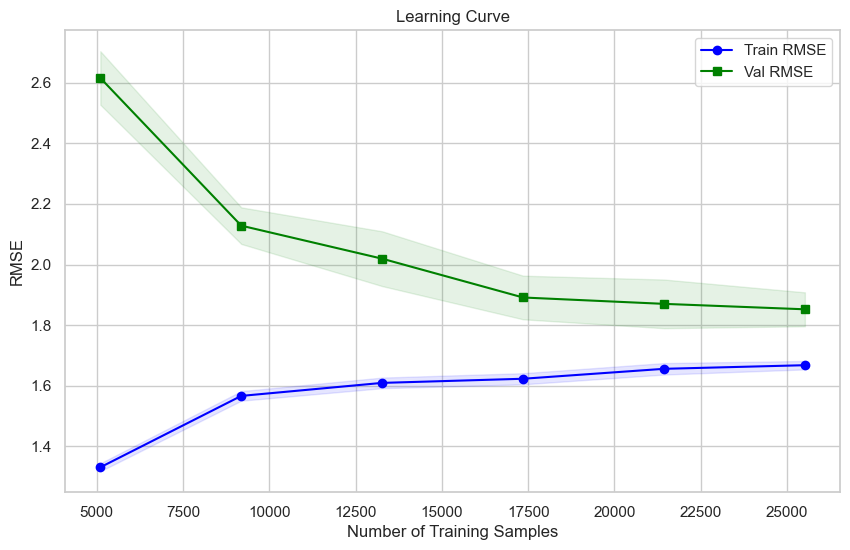

In [77]:
custom_learning_curve(overfit_poly, np.linspace(0.01, 0.05, 6))

In [36]:
overfit_poly.fit(X_train[:25000], y_train[:25000])
evaluate_model(overfit_poly, X_test, y_test, "Linear Regression with polynomial features")



Linear Regression with polynomial features Results:
RMSE: $1.82


1.8189874128714951

In [38]:
cross_validate_model(overfit_poly, 20000)

Training RMSE: 1.64
Validation RMSE: 1.87 (+/- 0.07)


In [125]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())       
])

lr_pipeline.fit(X_train, y_train)
evaluate_model(lr_pipeline, X_test, y_test, "Linear Regression")

poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)), 
    ('regressor', LinearRegression())       
])

poly_pipeline.fit(X_train[:25000], y_train[:25000])
evaluate_model(poly_pipeline, X_test, y_test, "Linear Regression with polynomial features")



Linear Regression Results:
RMSE: $2.49
R2 Score: 0.9287

Linear Regression with polynomial features Results:
RMSE: $1.82
R2 Score: 0.9620


(1.8189874128714951, 0.9620474974819638)

In [118]:
from sklearn.model_selection import GridSearchCV

param_grid_ada = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 1.0],
    'regressor__estimator__max_depth': [5, 10, 15]
}

grid_ada = GridSearchCV(adaboost_pipeline, param_grid_ada, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_ada.fit(X_train[:20000], y_train[:20000])

print(f"Best params: {grid_ada.best_params_}")
evaluate_model(grid_ada.best_estimator_, X_test, y_test, "Tuned AdaBoost")

Best params: {'regressor__estimator__max_depth': 15, 'regressor__learning_rate': 0.01, 'regressor__n_estimators': 100}

Tuned AdaBoost Results:
RMSE: $1.91
R2 Score: 0.9580


(1.9127790627473333, 0.9580327367791807)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_dist_svm = {
    'regressor__C': loguniform(1, 300),
    'regressor__epsilon': [0.01, 0.1, 0.5],
    'regressor__gamma': ['scale', 'auto']
}

random_svm = RandomizedSearchCV(svm_pipeline, param_dist_svm, n_iter=10, cv=3, random_state=42, n_jobs=-1)
random_svm.fit(X_train[:15000], y_train[:15000])

print(f"Best params: {random_svm.best_params_}")
evaluate_model(random_svm.best_estimator_, X_test, y_test, "Tuned SVM")

Best params: {'regressor__C': np.float64(255.20484589960955), 'regressor__epsilon': 0.5, 'regressor__gamma': 'auto'}

Tuned SVM Results:
RMSE: $1.97
R2 Score: 0.9556


(1.9681083543861344, 0.9555697210547748)

In [121]:
base_learner = DecisionTreeRegressor(max_depth=15) 
adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators=100, learning_rate=0.01, random_state=42, estimator=base_learner))
])

adaboost_pipeline.fit(X_train[:50000], y_train[:50000])
evaluate_model(adaboost_pipeline, X_test, y_test, "Adaboost")



Adaboost Results:
RMSE: $1.83
R2 Score: 0.9617


(1.8272325183669276, 0.9617026555197823)

In [124]:

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=255.0, epsilon=0.5, gamma = 'auto'))
])

svm_pipeline.fit(X_train[:25000], y_train[:25000])
evaluate_model(svm_pipeline, X_test, y_test, "SVM (RBF Kernel)")



SVM (RBF Kernel) Results:
RMSE: $1.90
R2 Score: 0.9587


(1.8976369837460378, 0.958694555328394)

In [112]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

estimators = [
    ('lr', lr_pipeline),
    ('poly', poly_pipeline),
    ('svm', svm_pipeline),
    ('adaboost', adaboost_pipeline)
]

# 2. Initialize the Stacking Regressor
# Ridge is used as the 'final_estimator' (meta-learner)
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,            # Uses 5-fold cross-validation to train the meta-learner
    n_jobs=-1,       # Use all available CPU cores
    passthrough=False # Set to True if you want the meta-learner to see raw data + predictions
)

# 3. Fit the model
# Stacking takes longer to train because of the internal cross-validation
stacking_model.fit(X_train[:25000], y_train[:25000])

# 4. Evaluate
evaluate_model(stacking_model, X_test, y_test, "Stacking Regressor")


Stacking Regressor Results:
RMSE: $1.79
R2 Score: 0.9632


(1.7914684022872207, 0.9631871589888737)